# Customer Retention and Churn Analysis

## Task 2 | Future Interns - Data Science & Analytics Internship (2026)

### Project Overview

This project focuses on Customer Retention & Churn Analysis, evaluating subscription-based behavior to identify why customers leave and what drives long-term loyalty. By applying cohort analysis and lifetime metrics, the goal is to provide data-driven strategies that minimize churn and maximize the Customer Lifetime Value (CLV).

### Dataset Description

The analysis is conducted using the Telco Customer Churn Dataset, which contains information about 7,043 customers at a California-based telecommunications company. It includes demographics, account information (tenure, contract type, payment method), and service usage details.

### Objectives & Methodology

The workflow for this project involves:

- Data Preparation: Handling missing values in total charges, encoding categorical variables, and segmenting tenure into logical cohorts.
- Cohort Analysis: Grouping customers by their signup period and contract type to track retention behavior over time.
- Feature Correlation: Identifying the key drivers—such as contract duration or technical support access—that have the highest correlation with customer churn.
- Predictive Insights: Using exploratory data analysis to pinpoint high-risk segments before they churn.
- Strategic Reporting: Developing a Power BI Dashboard that translates complex retention metrics into actionable business recommendations.

### Research Questions

To guide the analysis, this project seeks to answer:

- Churn Patterns: What is the overall churn rate, and how does it fluctuate across different customer segments (e.g., Senior Citizens vs. Families)?
- Retention Drivers: Which services (Online Security, Tech Support, Streaming) are most effective at keeping customers engaged?
- Contractual Impact: How do month-to-month contracts compare to one- or two-year commitments in terms of stability and revenue?
- Revenue Leakage: What is the estimated monthly revenue loss associated with churning customers?
- Actionable Strategy: What specific interventions (e.g., loyalty programs or plan upgrades) can be implemented to improve retention in high-risk groups?

## DATA PREPROCESSING

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
data = pd.read_csv('customer_data.csv')

In [46]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [47]:
data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


This dataset provides details on customer demographic traits, service subscriptions, and billing details are linked to a binary Churn indicator, providing the foundation for identifying which specific variables most strongly correlate with customer loss.

In [48]:
data.shape

(7043, 21)

The dataset contains 21 column attributes and 7043 row entries.

In [49]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


The summary statistics indicate a diverse customer base with an average tenure of roughly 32 months and monthly charges averaging 64.76, while the low mean for senior citizens (0.16) suggests the majority of the subscriber population is younger.

## DATA CLEANING

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


There is a need for data type conversion as TotalCharges is currently stored as an object rather than a numeric float.

In [51]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

data['TotalCharges'] = data['TotalCharges'].fillna(0)

In [52]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

There are no missing values in the data so we go on to check for duplicates

In [53]:
data.duplicated().sum()

0

There are no duplicates in the dataset so we check for outliers

In [54]:
kurtosis_values = data.select_dtypes(include=['number']).kurt()

print("Kurtosis values:")
print(kurtosis_values)

Kurtosis values:
SeniorCitizen     1.362596
tenure           -1.387372
MonthlyCharges   -1.257260
TotalCharges     -0.228580
dtype: float64


Kurtosis values are less than 3 which means we likely do not have extreme values or errors. The kurtosis values confirm that the data is non-normally distributed, specifically highlighting that customers cluster at the extreme ends of the tenure spectrum rather than around a central average. We also see that monthly billing is highly diverse and segmented while the total revenue contributed per customer follows a more predictable, traditional pattern.

In [55]:
# standardise column names 

rename_dict = {
    'customerID': 'customer_id',
    'SeniorCitizen': 'senior_citizen',
    'Partner': 'partner',
    'Dependents': 'dependents',
    'PhoneService': 'phone_service',
    'MultipleLines': 'multiple_lines',
    'InternetService': 'internet_service',
    'OnlineSecurity': 'online_security',
    'OnlineBackup': 'online_backup',
    'DeviceProtection': 'device_protection',
    'TechSupport': 'tech_support',
    'StreamingTV': 'streaming_tv',
    'StreamingMovies': 'streaming_movies',
    'Contract': 'contract',
    'PaperlessBilling': 'paperless_billing',
    'PaymentMethod': 'payment_method',
    'MonthlyCharges': 'monthly_charges',
    'TotalCharges': 'total_charges',
    'Churn' : 'churn'
}

data.rename(columns=rename_dict, inplace=True)

In [56]:
data.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [57]:
# Check the number of unique values
unique_counts = data['customer_id'].nunique()
total_rows = len(data)

print(f"Unique Customer IDs: {unique_counts}")
print(f"Total Rows: {total_rows}")

Unique Customer IDs: 7043
Total Rows: 7043


Since the number of unique customer id's match the total number of rows, customer_id is just an identifier and can be dropped 

In [58]:
data.drop(columns=['customer_id'], inplace=True)

In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             7043 non-null   object 
 1   senior_citizen     7043 non-null   int64  
 2   partner            7043 non-null   object 
 3   dependents         7043 non-null   object 
 4   tenure             7043 non-null   int64  
 5   phone_service      7043 non-null   object 
 6   multiple_lines     7043 non-null   object 
 7   internet_service   7043 non-null   object 
 8   online_security    7043 non-null   object 
 9   online_backup      7043 non-null   object 
 10  device_protection  7043 non-null   object 
 11  tech_support       7043 non-null   object 
 12  streaming_tv       7043 non-null   object 
 13  streaming_movies   7043 non-null   object 
 14  contract           7043 non-null   object 
 15  paperless_billing  7043 non-null   object 
 16  payment_method     7043 

In [60]:
cols_to_check = ['online_security', 'online_backup', 'device_protection', 
                 'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines']

print("Unique Values")
for col in cols_to_check:
    print(f"{col}: {data[col].unique()}")

Unique Values
online_security: ['No' 'Yes' 'No internet service']
online_backup: ['Yes' 'No' 'No internet service']
device_protection: ['No' 'Yes' 'No internet service']
tech_support: ['No' 'Yes' 'No internet service']
streaming_tv: ['No' 'Yes' 'No internet service']
streaming_movies: ['No' 'Yes' 'No internet service']
multiple_lines: ['No phone service' 'No' 'Yes']


For these columns , 'No internet service' and 'No phone service' is equivalent to 'No' so we convert these to just 'No' for easier analysis

In [61]:
cols_to_fix = ['online_security', 'online_backup', 'device_protection', 
               'tech_support', 'streaming_tv', 'streaming_movies']

for col in cols_to_fix:
    data[col] = data[col].replace('No internet service', 'No')

data['multiple_lines'] = data['multiple_lines'].replace('No phone service', 'No')

In [62]:
all_binary_cols = [
    'partner', 'dependents', 'phone_service', 'multiple_lines', 
    'online_security', 'online_backup', 'device_protection', 
    'tech_support', 'streaming_tv', 'streaming_movies', 
    'paperless_billing', 'churn'
]

for col in all_binary_cols:
    data[col] = data[col].map({'Yes': 1, 'No': 0})

Binary encoded the Yes/No columns for better visualisations and analysis

In [63]:
# checking for constant columns 

data.nunique()

gender                  2
senior_citizen          2
partner                 2
dependents              2
tenure                 73
phone_service           2
multiple_lines          2
internet_service        3
online_security         2
online_backup           2
device_protection       2
tech_support            2
streaming_tv            2
streaming_movies        2
contract                3
paperless_billing       2
payment_method          4
monthly_charges      1585
total_charges        6531
churn                   2
dtype: int64

Since no column has only one unique value, every feature contains at least some variation that could help explain why customers stay or leave, making them all potentially useful for churn analysis.

In [64]:
data.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [65]:
# save the final cleaned data 

data.to_csv('data_cleaned.csv', index=False)

## DATA ANALYSIS AND EXPLORATION

This section loads the cleaned dataset and performs exploratory analysis to uncover patterns, statistical relationships, and key churn drivers.

In [2]:
import pandas as pd

data = pd.read_csv('data_cleaned.csv')
data.head()

c:\Users\raees\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\raees\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway

my_palette = ["#648FFF", "#785EF0", "#DC267F", "#FE6100", "#FFB000"]
sns.set_palette(my_palette)

plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

In [5]:
# Calculate baseline Churn Rate
churn_rate = data['churn'].mean() * 100
print(f"\nOverall Churn Rate: {churn_rate:.2f}%")


Overall Churn Rate: 26.54%


Just over a quarter of customers have left within the last month. This is a very high churn rate and needs to be investigated further 

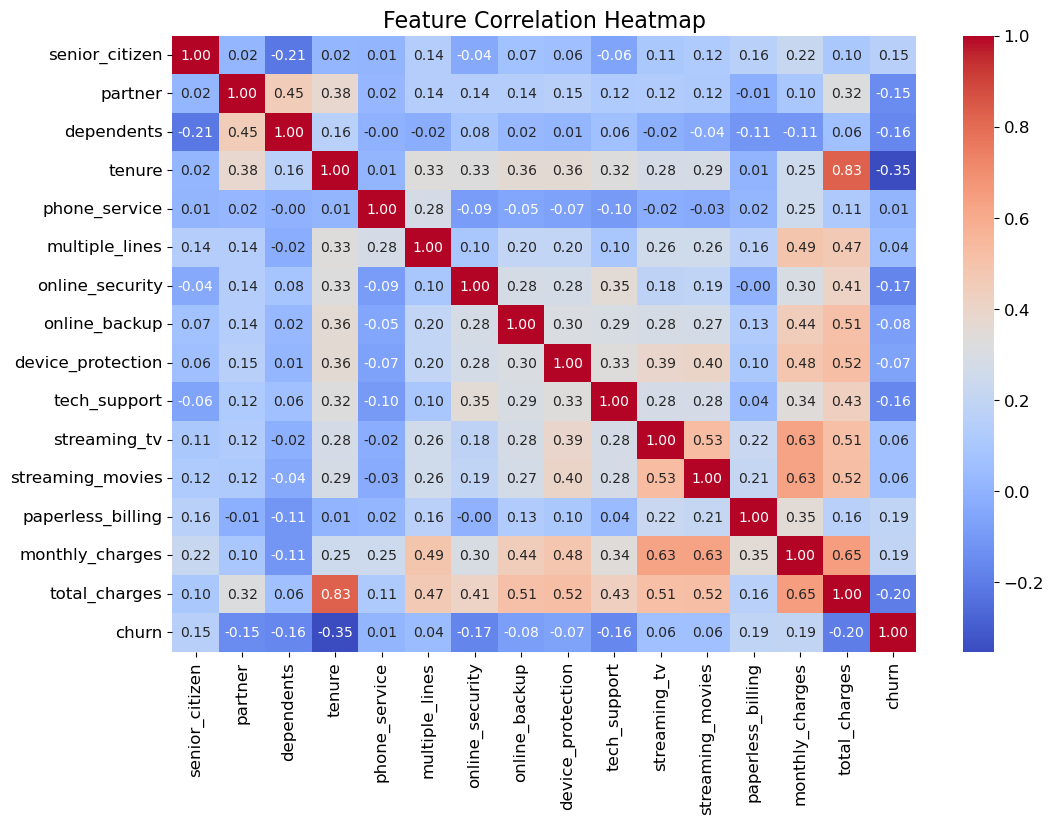

In [8]:
import numpy as np

plt.figure(figsize=(12, 8))

corr_matrix = data.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

Heatmap of feature correlations identifying tenure and contract as the strongest drivers of retention, suggesting that long-term commitments significantly reduce the likelihood of churn.

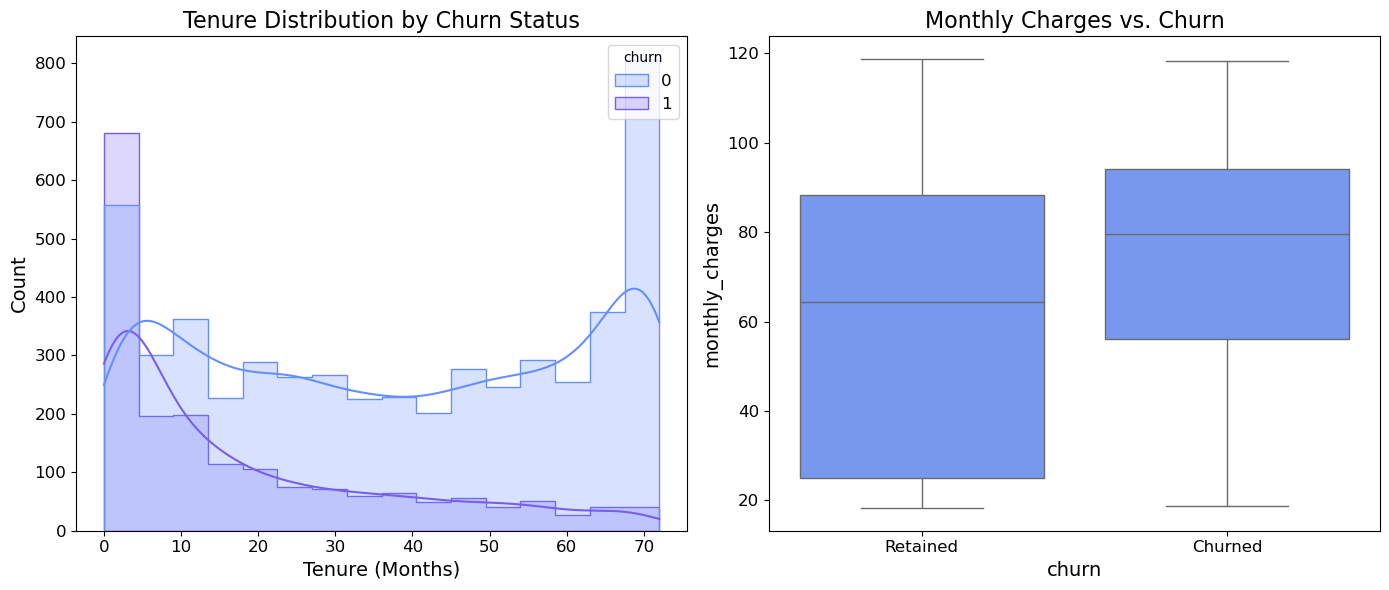

In [6]:
plt.figure(figsize=(14, 6))

# Tenure Distribution
plt.subplot(1, 2, 1)
sns.histplot(data=data, x='tenure', hue='churn', kde=True, element="step")
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")

# Monthly Charges Comparison
plt.subplot(1, 2, 2)
sns.boxplot(x='churn', y='monthly_charges', data=data)
plt.title("Monthly Charges vs. Churn")
plt.xticks([0, 1], ['Retained', 'Churned'])

plt.tight_layout()
plt.show()

We can see that customers often churn early in their tenure, and higher monthly charges correlate with higher churn.

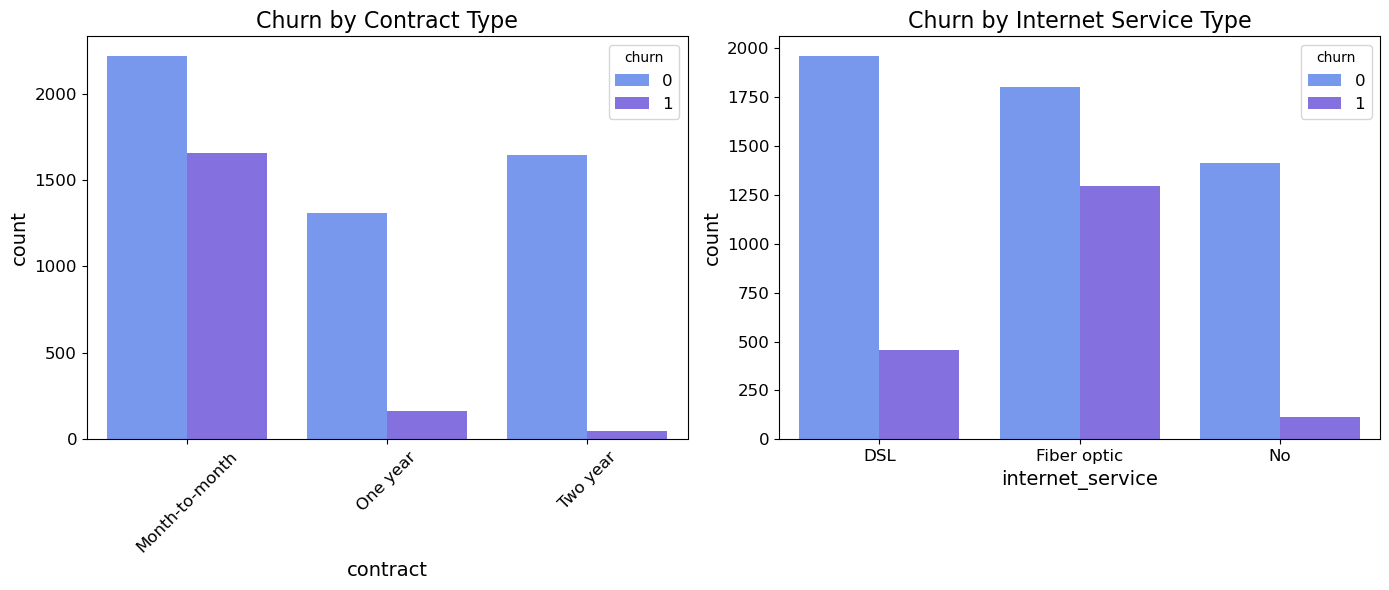

In [9]:
plt.figure(figsize=(14, 6))

# Churn by Contract Type
plt.subplot(1, 2, 1)
sns.countplot(x='contract', hue='churn', data=data)
plt.title("Churn by Contract Type")
plt.xticks(rotation=45)

# Churn by Internet Service
plt.subplot(1, 2, 2)
sns.countplot(x='internet_service', hue='churn', data=data)
plt.title("Churn by Internet Service Type")

plt.tight_layout()
plt.show()

- Distribution of customer churn by contract type reveals that month-to-month subscribers represent the highest risk group, highlighting the importance of long-term contracts as a primary retention driver.
- Comparison of internet service categories reveals that Fiber optic subscribers churn at a much higher frequency than DSL users, indicating that service-specific factors such as pricing or reliability in the high-speed tier are significant drivers of customer loss.

In [10]:
contingency_table = pd.crosstab(data['contract'], data['churn'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Test P-Value (Contract vs Churn): {p:.4f}")

Chi-Square Test P-Value (Contract vs Churn): 0.0000


The Chi-Square p-value of 0.0000 confirms with near-absolute statistical certainty that contract type is not independent of churn, validating it as one of the most significant predictors in our analysis.

In [11]:
group_retained = data[data['churn'] == 0]['monthly_charges']
group_churned = data[data['churn'] == 1]['monthly_charges']

f_stat, p_val = f_oneway(group_retained, group_churned)
print(f"ANOVA P-Value (Monthly Charges vs Churn): {p_val:.4f}")

ANOVA P-Value (Monthly Charges vs Churn): 0.0000


The ANOVA p-value of 0.0000 provides strong statistical evidence that mean monthly charges differ significantly between churned and retained customers, confirming that pricing is a critical factor in subscription longevity.

Text(0.5, 1.0, 'Churn Rate by Family Status')

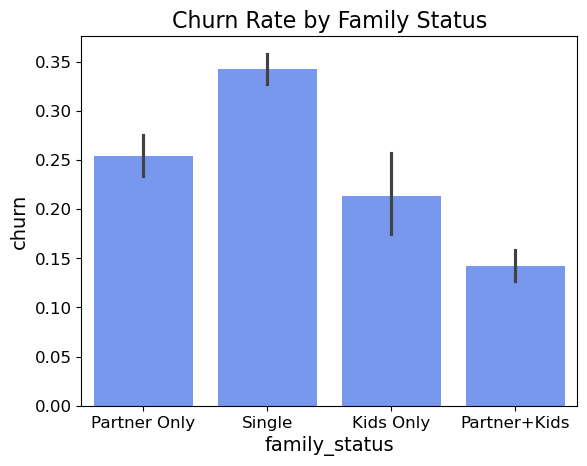

In [12]:
# Senior citizen churn rate vs non-senior
senior_churn = data.groupby('senior_citizen')['churn'].mean() * 100

# Family structure: partner + dependents combos
data['family_status'] = data.apply(
    lambda x: 'Partner+Kids' if x['partner']==1 and x['dependents']==1
    else ('Partner Only' if x['partner']==1
    else ('Kids Only' if x['dependents']==1 else 'Single')), axis=1)

sns.barplot(x='family_status', y='churn', data=data)
plt.title("Churn Rate by Family Status")

Analysis of family status reveals that customers with partners or dependents are significantly more likely to remain with the service, identifying single-person households as a higher-risk segment that may require more personalized retention strategies.

<AxesSubplot:xlabel='churn', ylabel='num_services'>

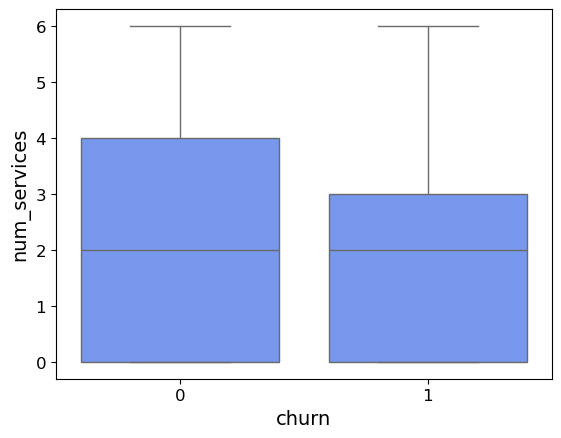

In [13]:
service_cols = ['online_security','tech_support','online_backup',
                'device_protection','streaming_tv','streaming_movies']

churn_by_service = {col: data.groupby(col)['churn'].mean()*100 
                    for col in service_cols}

data['num_services'] = data[service_cols].sum(axis=1)
sns.boxplot(x='churn', y='num_services', data=data)

Customers who bundle multiple offerings (such as Tech Support and Online Security) have significantly higher retention rates than those on single-service plans.

C:\Users\raees\AppData\Local\Temp\ipykernel_1908\50544339.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_cohort = data.groupby('tenure_cohort')['churn'].mean() * 100


<AxesSubplot:xlabel='tenure_cohort', ylabel='churn'>

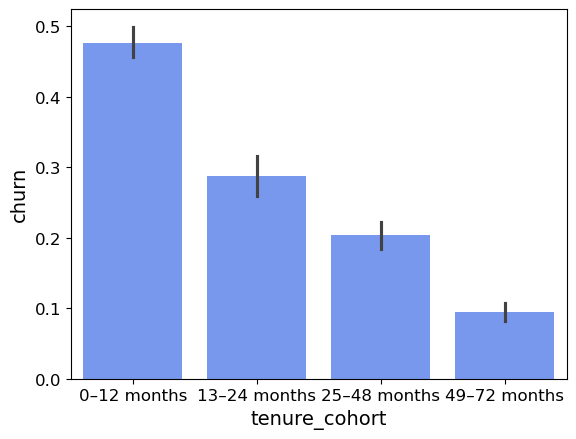

In [14]:
# Segment customers into tenure cohorts
bins = [0, 12, 24, 48, 72]
labels = ['0–12 months', '13–24 months', '25–48 months', '49–72 months']
data['tenure_cohort'] = pd.cut(data['tenure'], bins=bins, labels=labels)

churn_by_cohort = data.groupby('tenure_cohort')['churn'].mean() * 100
sns.barplot(x='tenure_cohort', y='churn', data=data)

The cohort analysis clearly illustrates that churn risk is highest within the first 12 months of a subscription, highlighting a "critical window" where proactive engagement is essential to securing the long-term loyalty observed in higher-tenure segments.

In [17]:
contingency_table = pd.crosstab(data['payment_method'], data['churn'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Test P-Value (Payment Method vs Churn): {p:.4f}")

Chi-Square Test P-Value (Payment Method vs Churn): 0.0000


The Chi-Square p-value of 0.0000 confirms with near-absolute statistical certainty that payment method is not independent of churn, validating it as one of the most significant predictors in our analysis.

Text(0.5, 1.0, 'Churn Rate by Payment Method')

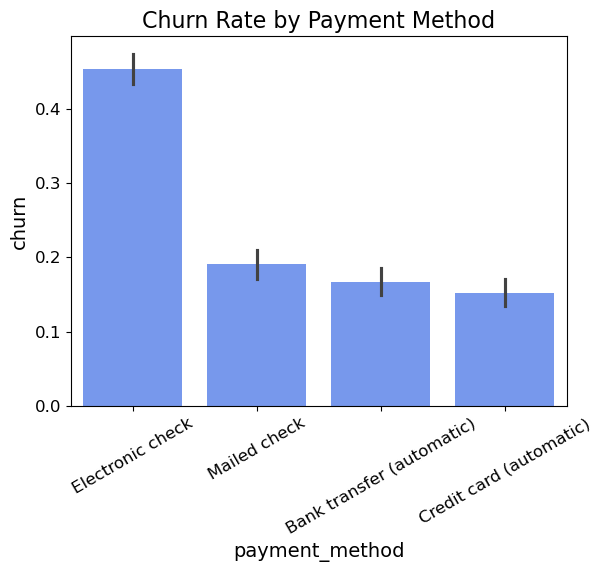

In [16]:
sns.barplot(x='payment_method', y='churn', data=data)
plt.xticks(rotation=30)
plt.title("Churn Rate by Payment Method")

The visualization reveals that customers using Electronic Checks experience disproportionately higher churn rates compared to those on automated payment methods like Credit Card or Bank Transfer, suggesting that friction in manual billing or payment failures significantly impacts long-term retention.

In [19]:
contingency = pd.crosstab(data['gender'], data['churn'])
chi2, p, dof, _ = chi2_contingency(contingency)
print(f"Chi-Square Test P-Value (Gender vs Churn): {p:.4f}")

Chi-Square Test P-Value (Gender vs Churn): 0.4866


The p-value is greater than 0.05 so gender is not a predictor of churn

### REVENUE IMPACT & CUSTOMER LIFETIME VALUE

Quantifying the financial cost of churn and comparing CLV between churned and retained customers.

In [15]:
monthly_loss = data[data['churn']==1]['monthly_charges'].sum()
avg_tenure_churned = data[data['churn']==1]['tenure'].mean()
estimated_ltv_loss = data[data['churn']==1]['total_charges'].sum()

print(f"Monthly Revenue at Risk: ${monthly_loss:,.2f}")
print(f"Total Lifetime Value Lost: ${estimated_ltv_loss:,.2f}")
print(f"Average Churned Customer Tenure: {avg_tenure_churned:.1f} months")

Monthly Revenue at Risk: $139,130.85
Total Lifetime Value Lost: $2,862,926.90
Average Churned Customer Tenure: 18.0 months


The analysis reveals that the business faces a staggering $139,130.85 in monthly revenue leakage and a cumulative lifetime loss of over $2.8 million, largely driven by customers who depart at an average tenure of just 18 months.

Text(0.5, 1.0, 'Customer Lifetime Value: Churned vs Retained')

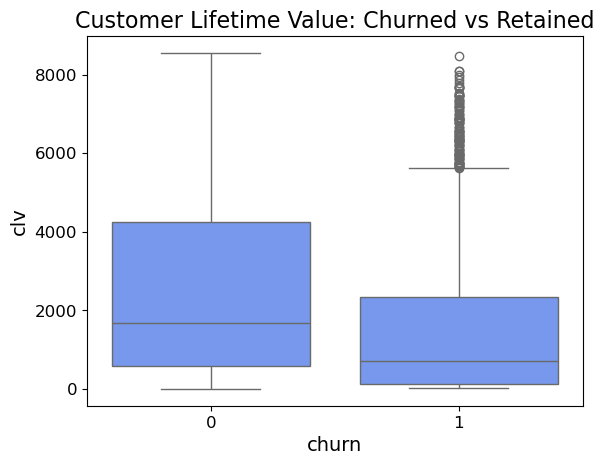

In [20]:
# Simple CLV proxy
data['clv'] = data['monthly_charges'] * data['tenure']

# Compare CLV distribution: churned vs retained
sns.boxplot(x='churn', y='clv', data=data)
plt.title("Customer Lifetime Value: Churned vs Retained")

The boxplot illustrates the distribution of Customer Lifetime Value (CLV) across churn categories , revealing that churned customers often have a higher median lifetime value, which represents a critical loss of high-value revenue for the business.

### HIGH-RISK SEGMENT PROFILE

Combining the key churn drivers identified above to define the customer profile most likely to churn.

In [21]:
# Who is the "most likely to churn" customer?
high_risk = data[
    (data['contract'] == 'Month-to-month') &
    (data['tenure'] <= 12) &
    (data['internet_service'] == 'Fiber optic') &
    (data['tech_support'] == 0)
]

print(f"High-risk segment size: {len(high_risk)}")
print(f"Churn rate in this segment: {high_risk['churn'].mean()*100:.1f}%")

High-risk segment size: 833
Churn rate in this segment: 71.1%


This analysis defines the high-risk customer profile as a month-to-month subscriber with high monthly charges and Fiber Optic service, typically departing within their first year, which serves as a roadmap for prioritizing retention interventions.

## TOP FINDINGS

1. **Churn Rate is Alarmingly High** : 
The overall churn rate stands at 26.5%, more than 1 in 4 customers left within the last month. This far exceeds healthy industry benchmarks (~5–7% for telecoms) and represents an urgent business problem.

2. **Contract Type is the Single Strongest Churn Predictor** :
Month-to-month subscribers churn at a dramatically higher rate than customers on one- or two-year contracts (χ² p < 0.0001). Contract type is the most actionable retention lever available.

3. **Early Tenure is a Critical Vulnerability Window** :
Churn is highest in the first 12 months. Customers who survive past 24 months are far more likely to stay long-term, the first year is make-or-break.

4. **Fiber Optic Customers Churn More Than DSL Users** :
Despite being the premium tier, Fiber Optic subscribers churn disproportionately, pointing to unmet expectations around price-to-value.

5. **Higher Monthly Charges Drive Churn** :
ANOVA confirms churned customers pay significantly more on average (p < 0.0001), indicating price sensitivity is a key departure driver.

6. **Service Bundling Strongly Improves Retention** :
Customers with multiple add-ons (particularly Tech Support and Online Security) churn at significantly lower rates. Each additional service raises switching costs and perceived value.

7. **Electronic Check Payments Are a Churn Signal** : 
Electronic check users churn at a notably higher rate than those on automated payment methods, suggesting payment friction correlates with disengagement.

8. **Single-Person Households Are High-Risk** :
Customers without a partner or dependents churn more frequently. Family units have greater inertia, singles need more personalised retention effort.

9. **The Revenue Cost is Substantial** : 
Monthly revenue at risk: ~$139,131 | Total lifetime value lost: ~$2.86 million | Average churned tenure: ~18 months. The business is losing customers before they reach their full revenue potential.

10. **Gender Has No Impact on Churn** : 
Chi-square testing confirms gender is not a significant predictor (p > 0.05), segmentation strategies based on gender would be misdirected.

## RECOMMENDATIONS

1. **Convert Month-to-Month Customers to Annual Contracts** :
Offer a meaningful incentive, such as 1–2 months free, a locked-in rate, or a service upgrade to encourage month-to-month subscribers onto annual plans. Even a modest conversion rate would substantially reduce churn.

2. **Launch a 90-Day Early Engagement Programme** :
Implement a structured onboarding journey: welcome call at day 7, check-in at day 30, value-review at day 90. Proactively surface unused features. The goal is to accelerate the loyalty threshold before customers disengage.

3. **Address Fiber Optic Pricing & Perceived Value** :
Audit the Fiber Optic experience via complaint logs, NPS, and support tickets. Consider a price-lock guarantee for the first 12 months, or bundle Tech Support into Fiber plans at no extra cost to close the price-to-value gap.

4. **Bundle Add-On Services for At-Risk Customers** :
Offer free 3-month trials of Tech Support and Online Security to single-service, month-to-month customers. Trial usage increases stickiness; even partial conversion to paid bundles reduces churn meaningfully.

5. **Migrate Customers Off Electronic Check Payments** :
Run a targeted campaign incentivising electronic check users to switch to auto-pay with a small monthly discount ($3–5). Reducing payment friction removes a low-visibility but real churn trigger.

6. **Design a Retention Programme for Single-Person Households** : 
Create a solo-focused value proposition, lexible pause options, loyalty points, referral bonuses, that builds switching costs for customers without the natural inertia of a family plan.

7. **Implement a Predictive Churn Alert System** :
The high-risk profile is well-defined: month-to-month + ≤12 months tenure + Fiber Optic + no Tech Support. Use this as a rule-based CRM flag to trigger automatic retention outreach, a personalised call or discount offer, before the customer cancels.

8. **Prioritise Retention Spend by CLV Tier** :
Segment the churn pipeline by customer lifetime value. High-CLV customers showing churn signals warrant white-glove treatment (dedicated contact, bespoke offers) since the cost of retention is far lower than the revenue lost.